In [307]:
import numpy as np
import math
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X, y = data.data, data.target

np.random.seed(42)
indices = np.random.permutation(len(X))
train_end = int(0.7 * len(X))
val_end = int(0.85 * len(X))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [308]:
mu_train = np.mean(X_train, axis=0)
sigma_train = np.std(X_train, axis=0)

X_train_scaled = (X_train - mu_train) / sigma_train
X_val_scaled = (X_val - mu_train) / sigma_train
X_test_scaled = (X_test - mu_train) / sigma_train

In [309]:
def calculate_iteration_budget(N, B, E):
    I = math.ceil(N / B)
    U = E * I
    return I, U

I, U = calculate_iteration_budget(14448, 64, 50)
print(f"I: {I}, U: {U}")

I: 226, U: 11300


In [310]:
import numpy as np
import time

class LinearRegressionVectorized:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iters = iterations
        self.w = None
        self.b = None

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0

        for _ in range(self.iters):
            y_hat = np.dot(X, self.w) + self.b
            error = y_hat - y

            dw = (1 / m) * np.dot(X.T, error)
            db = (1 / m) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [311]:
def normal_equations(X, y):
    m = X.shape
    X_aug = np.c_[np.ones(m), X]
    theta_best = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y
    return theta_best, theta_best[1:]

In [312]:
start_gd = time.time()

model_gd = LinearRegressionVectorized(learning_rate=0.1, iterations=1000)

model_gd.fit(X_train_scaled, y_train)

end_gd = time.time()

start_ne = time.time()

b_ne, w_ne = normal_equations(X_train_scaled, y_train)

end_ne = time.time()

print(f"Gradient Descent Time: {end_gd - start_gd:.4f}s")

print(f"Normal Equations Time: {end_ne - start_ne:.4f}s")

Gradient Descent Time: 0.1506s
Normal Equations Time: 0.0080s


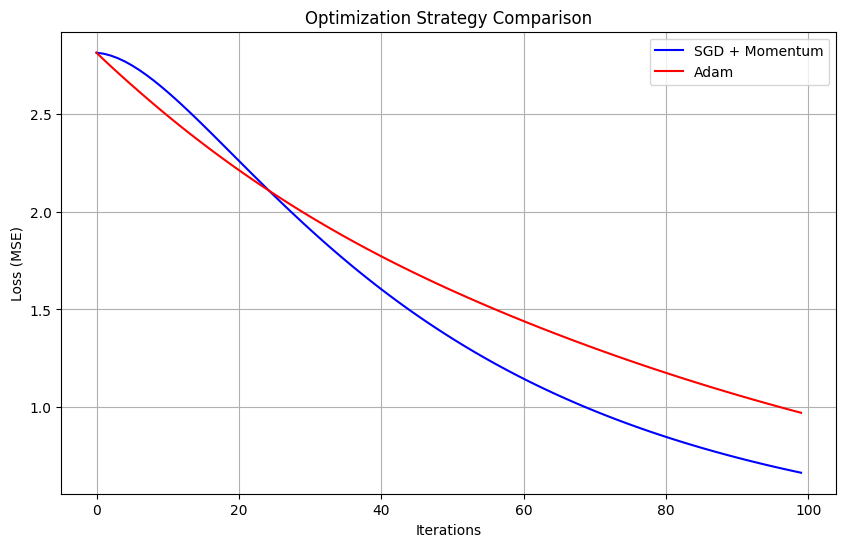

In [313]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionMomentum:
    def __init__(self, learning_rate=0.01, iters=1000, beta=0.9):
        self.lr = learning_rate
        self.iters = iters
        self.beta = beta
        self.w = None
        self.b = None

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        v_w = np.zeros(n)
        v_b = 0.0
        loss_history = []

        for _ in range(self.iters):
            y_hat = np.dot(X, self.w) + self.b
            error = y_hat - y
            dw = (1 / m) * np.dot(X.T, error)
            db = (1 / m) * np.sum(error)

            v_w = self.beta * v_w + (1 - self.beta) * dw
            v_b = self.beta * v_b + (1 - self.beta) * db
            self.w -= self.lr * v_w
            self.b -= self.lr * v_b
            mse = (1 / (2 * m)) * np.sum(error**2)
            loss_history.append(mse)
        return loss_history

class LinearRegressionAdam:
    def __init__(self, lr=0.001, iters=1000, b1=0.9, b2=0.999, epsilon=1e-8):
        self.lr = lr
        self.iters = iters
        self.b1 = b1
        self.b2 = b2
        self.eps = epsilon
        self.w = None
        self.b = None

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        m_w, v_w = np.zeros(n), np.zeros(n)
        m_b, v_b = 0.0, 0.0
        loss_history = []
        for t in range(1, self.iters + 1):
            y_hat = np.dot(X, self.w) + self.b
            error = y_hat - y
            dw = (1 / m) * np.dot(X.T, error)
            db = (1 / m) * np.sum(error)

            m_w = self.b1 * m_w + (1 - self.b1) * dw
            v_w = self.b2 * v_w + (1 - self.b2) * (dw**2)
            m_b = self.b1 * m_b + (1 - self.b1) * db
            v_b = self.b2 * v_b + (1 - self.b2) * (db**2)

            m_w_hat = m_w / (1 - self.b1**t)
            v_w_hat = v_w / (1 - self.b2**t)
            m_b_hat = m_b / (1 - self.b1**t)
            v_b_hat = v_b / (1 - self.b2**t)

            self.w -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.eps)
            self.b -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.eps)

            mse = (1 / (2 * m)) * np.sum(error**2)
            loss_history.append(mse)
        return loss_history
    def predict(self, X):
        return np.dot(X, self.w) + self.b
model_mom = LinearRegressionMomentum(learning_rate=0.01, iters=100)
history_mom = model_mom.fit(X_train_scaled, y_train)

model_adam = LinearRegressionAdam(lr=0.01, iters=100)
history_adam = model_adam.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.plot(history_mom, label='SGD + Momentum', color='blue')
plt.plot(history_adam, label='Adam', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.title('Optimization Strategy Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [314]:
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()
X_c, y_c = cancer_data.data, cancer_data.target

np.random.seed(42)
indices_c = np.random.permutation(len(X_c))
tr_end = int(0.7 * len(X_c))
v_end = int(0.85 * len(X_c))

X_train_c, y_train_c = X_c[indices_c[:tr_end]], y_c[indices_c[:tr_end]]
X_val_c, y_val_c = X_c[indices_c[tr_end:v_end]], y_c[indices_c[tr_end:v_end]]
X_test_c, y_test_c = X_c[indices_c[v_end:]], y_c[indices_c[v_end:]]

mu_c = np.mean(X_train_c, axis=0)
sigma_c = np.std(X_train_c, axis=0)

X_train_c = (X_train_c - mu_c) / sigma_c
X_val_c = (X_val_c - mu_c) / sigma_c
X_test_c = (X_test_c - mu_c) / sigma_c

In [315]:
class LogisticRegressionNumPy:
    def __init__(self, lr=0.01, iters=1000, l2_lambda=0.1):
        self.lr = lr
        self.iters = iters
        self.l2_lambda = l2_lambda
        self.w = None
        self.b = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0

        for _ in range(self.iters):
            z = np.dot(X, self.w) + self.b
            y_hat = self._sigmoid(z)
            error = y_hat - y

            dw = (1 / m) * np.dot(X.T, error) + (self.l2_lambda / m) * self.w
            db = (1 / m) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [316]:
model_log = LogisticRegressionNumPy(lr=0.1, iters=1000)
model_log.fit(X_train_c, y_train_c)

y_val_pred = model_log.predict(X_val_c)
accuracy = np.mean(y_val_pred == y_val_c)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9647


In [317]:
import numpy as np
from scipy import stats

class KNNVectorized:
    def __init__(self, k=3, task='classification'):
        self.k = k
        self.task = task
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _compute_distances(self, X_test):
        dist_sq = np.sum(X_test**2, axis=1)[:, np.newaxis] + \
                  np.sum(self.X_train**2, axis=1) - \
                  2 * np.dot(X_test, self.X_train.T)
        return np.sqrt(np.maximum(dist_sq, 0))

    def predict(self, X_test):
        distances = self._compute_distances(X_test)
        k_indices = np.argsort(distances, axis=1)[:, :self.k]
        k_nearest_labels = self.y_train[k_indices]

        if self.task == 'classification':
            predictions = stats.mode(k_nearest_labels, axis=1, keepdims=False)
        else:
            predictions = np.mean(k_nearest_labels, axis=1)

        return predictions

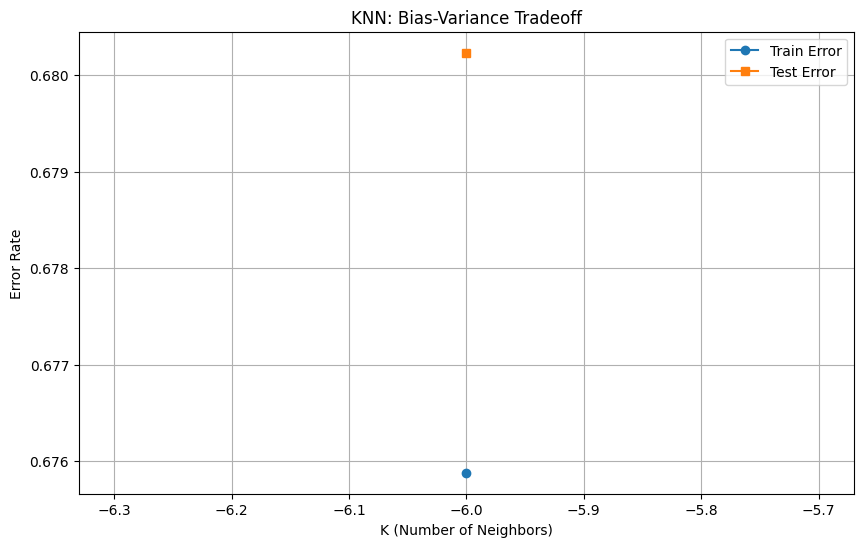

In [318]:
import matplotlib.pyplot as plt

k_values = [2-8]
train_errors = []
test_errors = []

for k in k_values:
    knn = KNNVectorized(k=k, task='classification')
    knn.fit(X_train_c, y_train_c)

    y_train_pred = knn.predict(X_train_c)
    train_errors.append(1 - np.mean(y_train_pred == y_train_c))

    y_test_pred = knn.predict(X_test_c)
    test_errors.append(1 - np.mean(y_test_pred == y_test_c))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, label='Train Error', marker='o')
plt.plot(k_values, test_errors, label='Test Error', marker='s')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

In [319]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt

alpha_l2 = 1.0
learning_rate = 0.01
m_samples = len(X_train_c)
shrinkage_factor = 1 - (learning_rate * (alpha_l2 / m_samples))

print(f"L2 Multiplicative Shrinkage Factor: {shrinkage_factor:.6f}")

L2 Multiplicative Shrinkage Factor: 0.999975


In [320]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_c, y_train_c)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_c, y_train_c)

ridge_zeros = np.sum(ridge.coef_ == 0)
lasso_zeros = np.sum(lasso.coef_ == 0)

print(f"Ridge zeroed-out weights: {ridge_zeros}")
print(f"Lasso zeroed-out weights: {lasso_zeros}")

Ridge zeroed-out weights: 0
Lasso zeroed-out weights: 26


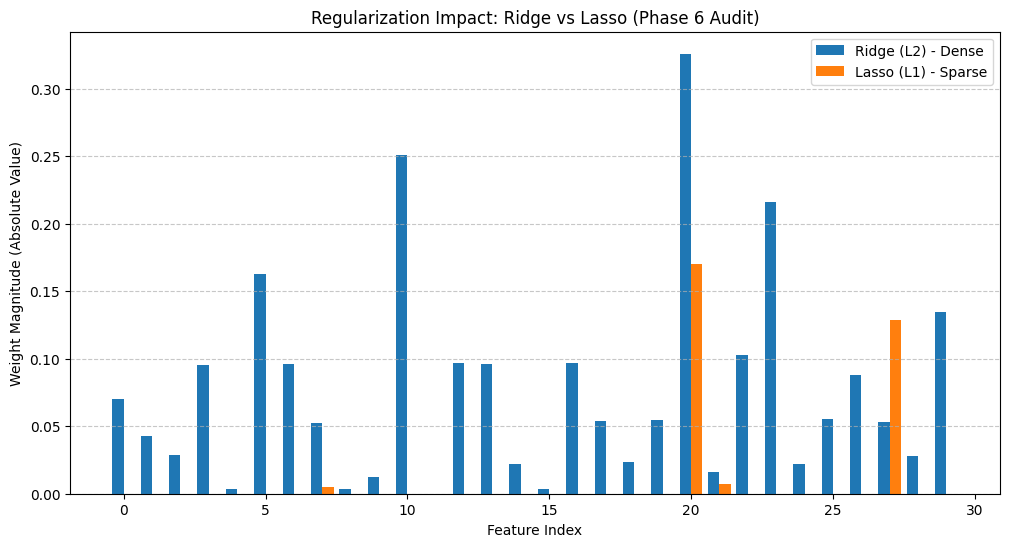

In [321]:
import numpy as np
import matplotlib.pyplot as plt
features = np.arange(X_train_c.shape[1])

plt.figure(figsize=(12, 6))
plt.bar(
    features - 0.2,
    np.abs(ridge.coef_),
    width=0.4,
    label='Ridge (L2) - Dense'
)
plt.bar(
    features + 0.2,
    np.abs(lasso.coef_),
    width=0.4,
    label='Lasso (L1) - Sparse'
)

plt.xlabel('Feature Index')
plt.ylabel('Weight Magnitude (Absolute Value)')
plt.title('Regularization Impact: Ridge vs Lasso (Phase 6 Audit)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Accuracy:  0.5116
Precision: 0.6182
Recall:    0.6182
F1 Score:  0.6182



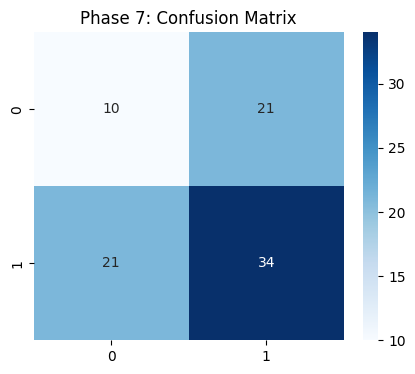

In [322]:
y_pred_log = model_log.predict(X_test_scaled_c)

cm = confusion_matrix(y_test_c, y_pred_log)
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_log):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_log):.4f}")
print(f"F1 Score:  {f1_score(y_test_c, y_pred_log):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Phase 7: Confusion Matrix')
plt.show()


In [323]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_adam = LinearRegressionAdam(lr=0.01, iters=1000)
model_adam.fit(X_train_h, y_train_h)

y_pred_reg = model_adam.predict(X_test_h)
mae = mean_absolute_error(y_test_h, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_reg))
r2 = r2_score(y_test_h, y_pred_reg)

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

MAE: 0.5210, RMSE: 0.7213, R2: 0.6066


1. Why is the bias term (b) omitted from L1 and L2 regularization?

Answer:
The bias (b) only moves the prediction up or down. It does not represent a feature. So, we apply regularization to the weights (w), not to the bias (b).

2. Why does Adam divide by (1-\beta_1^t)?

Answer:
At the beginning, Adam starts with (m_0=0). This makes the value of (m_t) smaller than the real value. Adam divides by (1-\beta_1^t) to correct this problem.

[
\hat{m}_t=\frac{m_t}{1-\beta_1^t}
]

This helps Adam get a better value for the gradient.

3. Derive the sigmoid derivative (\sigma'(z)=\sigma(z)(1-\sigma(z))).

Answer:


[
\sigma(z)=\frac{1}{1+e^{-z}}
]

After taking the derivative:

[
\sigma'(z)=\frac{e^{-z}}{(1+e^{-z})^2}
]

We also know:

[
\sigma(z)=\frac{1}{1+e^{-z}}
]

and:

[
1-\sigma(z)=\frac{e^{-z}}{1+e^{-z}}
]

So:

[
\boxed{\sigma'(z)=\sigma(z)(1-\sigma(z))}
]

4. Why does L1 produce sparse weights while L2 produces dense weights?

Answer:
L1 has a diamond shape with sharp corners. These corners can make some weights become exactly zero.

L2 has a smooth circle. It makes the weights smaller, but usually does not make them zero.

So:

[
L1 \rightarrow \text{Sparse weights}
]

[
L2 \rightarrow \text{Dense weights}
]